In [22]:
import numpy as np
import pandas as pd
import astropy.units as u
import astropy.constants as const
from astropy.time import Time
from astropy.coordinates import SkyCoord, CartesianRepresentation
import matplotlib.pyplot as plt
import spiceypy as spice

from light_deflection import delta_kpn, calc_CE, calc_der_E, calc_der_star, calc_CPE, calc_CO, calc_CT
from ephemeris import ephem_kernel, on_sky_velocity

In [23]:
kernel = ['/srv/jupyterhub/shared/data/kernels/jup365.bsp']

spice.furnsh(kernel)

In [24]:
# Occultation parameters
occ_time = Time('2020-12-21 00:46:00', scale='utc')

sun_spkid = '10'

sun_GM = (const.G * (1 * u.M_sun)).to(u.km**3 / u.s**2)


In [25]:
# Geocentric positions at the reference epoch
pos_sun, vel_sun = ephem_kernel(time=occ_time, target=sun_spkid, observer='500')
pos_sun = pos_sun.cartesian

d_sun = pos_sun.norm()
pos_sun = CartesianRepresentation(d_sun, 0, 0,  unit=u.AU) #a generic position for the Sun

pos_earth = CartesianRepresentation(0 * u.km, 0 * u.km, 0 * u.km)

pos_star = SkyCoord('20h09m33.4968s -20d35m38.7271s', distance=77.8972*u.pc)
d_sg1 = 77.8972 * u.pc

In [26]:
spice.kclear()

In [27]:
def deflec_vecs(pos_observer, pos_source, pos_massive, gm):
    vec_rso = pos_observer - pos_source
    vec_rao = pos_observer - pos_massive
    vec_ras = pos_source - pos_massive
    return delta_kpn(gm=gm, vec_rso=vec_rso, vec_rao=vec_rao, vec_ras=vec_ras)

In [28]:
def astrometric_correction_vs_angular_separation(massive_pos, gm_massive, observer,
                                            source_distance, target_distances, thetas):

    colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(target_distances)))
    results = {}
    tables = {}

    line_styles = [
        '-',                  # solid line
        (0, (5, 2)),          # long dash
        (0, (1, 1.5)),        # dense dotted
        (0, (5, 2, 1, 2)),    # well-defined dash-dot
    ]
    line_widths = [2.2, 2.2, 2.5, 2.2]
    markers = [None, None, None, None]

    plt.figure()
    for i, distance in enumerate(target_distances):
        data = []
        for theta in thetas:
            X_target = distance * np.cos(theta)
            Y_target = distance * np.sin(theta)
            target = CartesianRepresentation(X_target, Y_target, 0 * u.au)

            vec_obs_target = target - observer
            star_pos = target + vec_obs_target / vec_obs_target.norm() * source_distance

            vec_massive_obs = massive_pos - observer
            vec_obs_star = star_pos - observer
            coord_massive_obs = SkyCoord(vec_massive_obs)
            coord_obs_star = SkyCoord(vec_obs_star)
            sep = coord_massive_obs.separation(coord_obs_star)

            deflection_target = deflec_vecs(observer, target, massive_pos, gm_massive)
            deflection_star = deflec_vecs(observer, star_pos, massive_pos, gm_massive)

            deflection_diff = deflection_star - deflection_target
            sin_theta_diff = deflection_diff.norm().decompose().value
            sin_theta_diff = np.clip(sin_theta_diff, -1.0, 1.0)
            deflection_diff_angle = np.arcsin(sin_theta_diff)

            astrometric_correction = target.norm() * np.sin(deflection_diff_angle)

            v_unit = vec_obs_target / vec_obs_target.norm()

            apparent_direction = v_unit + deflection_target
            apparent_direction = apparent_direction / apparent_direction.norm()

            apparent_pos = target + apparent_direction * vec_obs_target.norm()
            coord_apparent = SkyCoord(apparent_pos, frame='icrs', representation_type='cartesian')

            coord_target = SkyCoord(target, frame='icrs', representation_type='cartesian')
            target_apparent_separation = coord_apparent.separation(coord_target)
            dra, ddec = coord_target.spherical_offsets_to(coord_apparent)

            data.append({
                'theta (deg)': np.degrees(theta),
                'separation_massive_star_deg': sep.deg,
                'astrometric_correction_km': astrometric_correction.to(u.km).value,
                'ra_target (deg)': coord_target.spherical.lon.deg,
                'dec_target (deg)': coord_target.spherical.lat.deg,
                'ra_apparent (deg)': coord_apparent.spherical.lon.deg,
                'dec_apparent (deg)': coord_apparent.spherical.lat.deg,
                'dra (mas)': dra.mas,
                'ddec (mas)': ddec.mas,
            })
        df = pd.DataFrame(data)
        tables[f'{distance.value} au'] = df

        results[f'{distance} au'] = {
            'separations': df['separation_massive_star_deg'].values,
            'C_E': df['astrometric_correction_km'].values,
        }

        x = df['separation_massive_star_deg'].values
        y = df['astrometric_correction_km'].values

        plt.plot(
            x,
            y,
            linestyle=line_styles[i % len(line_styles)],
            linewidth=line_widths[i % len(line_widths)],
            marker=markers[i % len(markers)],
            color=colors[i],
            label=f'{distance.value} au',
        )
        idx = int(0.75 * len(x))

        if idx >= len(x) - 1:
            idx = len(x) - 2

        dx = x[idx + 1] - x[idx - 1]
        dy = np.log10(y[idx + 1]) - np.log10(y[idx - 1])

        angle = np.degrees(np.arctan2(dy, dx))

        if angle > 90:
            angle -= 180
        elif angle < -90:
            angle += 180

        x_pos = x[idx]
        y_pos = y[idx]

        if i == 0:
            y_pos = y_pos / 2.75
            vertical_alignment = 'bottom'
        elif i == 1:
            y_pos = y_pos / 2.75
            vertical_alignment = 'bottom'
        elif i == 2:
            y_pos = y_pos * 1.10
            vertical_alignment = 'bottom'
        else:
            y_pos = y_pos * 2.5
            vertical_alignment = 'top'

        plt.annotate(
            f'{distance.value:g} au',
            (x_pos, y_pos),
            color=colors[i],
            fontsize=9,
            weight='bold',
            rotation=angle,
            rotation_mode='anchor',
            ha='center',
            va=vertical_alignment,
        )

    plt.xlabel(r'Angular separation from the Sun, $(\psi_\odot)$ (deg)', fontsize=12)
    plt.ylabel('Astrometric correction, $(C_E)$ (km)', fontsize=12)
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.savefig(f'C_E_psi.pdf', bbox_inches='tight')
    plt.show()

    return tables, results

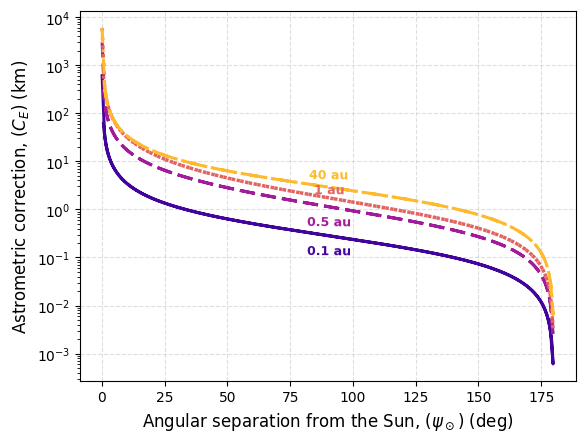

In [29]:
target_distances = [0.1, 0.5, 1, 40] * u.au
thetas = np.linspace(0.001, 2*np.pi-0.01, 361)

tables_sun, results_sun = astrometric_correction_vs_angular_separation(
    pos_sun, sun_GM, pos_earth, d_sg1, target_distances, thetas
)